<a href="https://colab.research.google.com/github/manjushreem0622-beep/IN126054202_Gen-Ai-/blob/main/Task_4_Fine_Tuning_BERT_on_a_Kaggle_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Fine-Tuning BERT on a Kaggle Dataset**

### **ASSIGNMENT NLP – 4**

## Objective
The objective of this assignment is to build a text classification model by fine-tuning a pre-trained BERT model on a Kaggle dataset. The process includes preprocessing text data, tokenization, training the model, evaluating performance, and comparing results from different experiments.

## **IMPORT LIBRARIES**

In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

import torch
from torch.utils.data import Dataset

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding

## **Load Dataset**
In this assignment, IMDB Movie Reviews dataset is used for sentiment classification.
It contains text reviews labeled as positive or negative.

In [5]:
df = pd.read_csv("IMDB Dataset.csv")
df = df.sample(10000, random_state=42)
df.head()

,review,sentiment
33553,I really liked this Summerslam due to the look...,positive
9427,Not many television shows appeal to quite as m...,positive
199,The film quickly gets to a major chase scene w...,negative
12447,Jane Austen would definitely approve of this o...,positive
39489,Expectations were somewhat high for me when I ...,negative


In [6]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 33553 to 5857
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     10000 non-null  object
 1   sentiment  10000 non-null  object
dtypes: object(2)
memory usage: 234.4+ KB


,0
review,0
sentiment,0


## **Data Preprocessing**
Text is cleaned by converting to lowercase, removing special characters, and eliminating extra spaces.

In [7]:
df = df.dropna()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["review"].apply(clean_text)
df.head()

,review,sentiment,clean_text
33553,I really liked this Summerslam due to the look...,positive,i really liked this summerslam due to the look...
9427,Not many television shows appeal to quite as m...,positive,not many television shows appeal to quite as m...
199,The film quickly gets to a major chase scene w...,negative,the film quickly gets to a major chase scene w...
12447,Jane Austen would definitely approve of this o...,positive,jane austen would definitely approve of this o...
39489,Expectations were somewhat high for me when I ...,negative,expectations were somewhat high for me when i ...


## **LABEL ENCODING**

In [8]:
label_map = {"positive": 1, "negative": 0}
df["label"] = df["sentiment"].map(label_map)

df[["clean_text", "label"]].head()

,clean_text,label
33553,i really liked this summerslam due to the look...,1
9427,not many television shows appeal to quite as m...,1
199,the film quickly gets to a major chase scene w...,0
12447,jane austen would definitely approve of this o...,1
39489,expectations were somewhat high for me when i ...,0


## **Data Splitting**
Dataset is split into training, validation, and testing sets.

In [9]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["clean_text"].tolist(),
    df["label"].tolist(),
    test_size=0.3,
    random_state=42,
    stratify=df["label"]
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print("Train:", len(train_texts))
print("Validation:", len(val_texts))
print("Test:", len(test_texts))

Train: 7000
Validation: 1500
Test: 1500


## **Tokenization**
Using bert-base-uncased tokenizer to convert text into tokens.

In [10]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=64)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=64)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=64)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## **DATASET CLASS**

In [11]:
class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = TextDataset(train_encodings, train_labels)
val_dataset = TextDataset(val_encodings, val_labels)
test_dataset = TextDataset(test_encodings, test_labels)

## **METRICS FUNCTION**

In [12]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

## **Experiment 1: Freeze BERT Layers**

In this experiment, all BERT layers are frozen and only the classifier layer is trained.  
This reduces training time but limits the model's ability to learn task-specific features.

In [13]:
model1 = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

for param in model1.bert.parameters():
    param.requires_grad = False

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [14]:
training_args1 = TrainingArguments(
    output_dir="./results1",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    report_to="none"
)

trainer1 = Trainer(
    model=model1,
    args=training_args1,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics
)

trainer1.train()
res1 = trainer1.evaluate(test_dataset)
print(res1)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.693484,0.504000,0.503541,0.504000,0.501611
2,0.700102,0.691587,0.520667,0.521323,0.520667,0.510026


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': 0.6926450729370117, 'eval_accuracy': 0.5033333333333333, 'eval_precision': 0.5023783326280152, 'eval_recall': 0.5033333333333333, 'eval_f1': 0.4921023007800928, 'eval_runtime': 5.2526, 'eval_samples_per_second': 285.571, 'eval_steps_per_second': 17.896, 'epoch': 2.0}


## **Experiment 2: Fine-Tune Last Two Layers**
In this experiment, the last two layers of BERT are fine-tuned along with the classifier. This allows the model to adapt better to the dataset and improves performance.

In [15]:
model2 = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

for param in model2.bert.parameters():
    param.requires_grad = False

for param in model2.bert.encoder.layer[-2:].parameters():
    param.requires_grad = True

for param in model2.classifier.parameters():
    param.requires_grad = True

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [16]:
training_args2 = TrainingArguments(
    output_dir="./results2",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    report_to="none"
)

trainer2 = Trainer(
    model=model2,
    args=training_args2,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics
)

trainer2.train()
res2 = trainer2.evaluate(test_dataset)
print(res2)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.432532,0.799333,0.799985,0.799333,0.799171
2,0.514900,0.422785,0.807333,0.807932,0.807333,0.807192


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': 0.4572555422782898, 'eval_accuracy': 0.7846666666666666, 'eval_precision': 0.7846648756958384, 'eval_recall': 0.7846666666666666, 'eval_f1': 0.7846654224250622, 'eval_runtime': 5.6841, 'eval_samples_per_second': 263.894, 'eval_steps_per_second': 16.537, 'epoch': 2.0}


## **CONFUSION MATRIX**

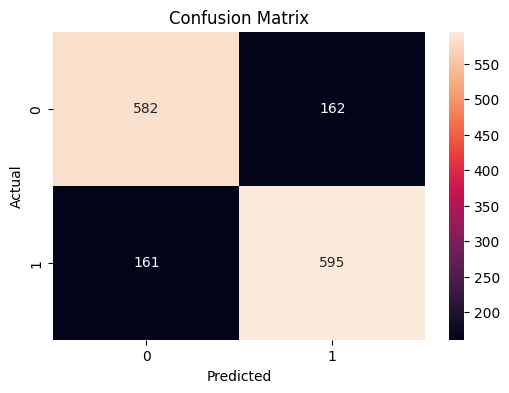

In [17]:
preds = trainer2.predict(test_dataset)
y_pred = np.argmax(preds.predictions, axis=1)

cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## **CLASSIFICATION REPORT**

In [18]:
print(classification_report(test_labels, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.78      0.78       744
           1       0.79      0.79      0.79       756

    accuracy                           0.78      1500
   macro avg       0.78      0.78      0.78      1500
weighted avg       0.78      0.78      0.78      1500



## **COMPARISON TABLE**

In [20]:
comparison = pd.DataFrame([
    ["Freeze BERT Layers", res1["eval_accuracy"], res1["eval_precision"], res1["eval_recall"], res1["eval_f1"]],
    ["Fine-Tune Last 2 Layers", res2["eval_accuracy"], res2["eval_precision"], res2["eval_recall"], res2["eval_f1"]]
], columns=["Experiment", "Accuracy", "Precision", "Recall", "F1 Score"])

comparison

,Experiment,Accuracy,Precision,Recall,F1 Score
0,Freeze BERT Layers,0.503333,0.502378,0.503333,0.492102
1,Fine-Tune Last 2 Layers,0.784667,0.784665,0.784667,0.784665


## Analysis

Experiment 1 resulted in lower accuracy because only the classifier layer was trained while all BERT layers were frozen.

Experiment 2 performed better because the last two BERT layers were fine-tuned, allowing the model to learn dataset-specific patterns.

This demonstrates that fine-tuning improves the performance of transformer-based models for text classification tasks.

## Conclusion

In this assignment, a BERT-based text classification model was successfully developed using the IMDB dataset.  
Two experiments were performed: freezing all BERT layers and fine-tuning the last two layers.  
The results clearly show that fine-tuning improves model performance by allowing it to learn dataset-specific patterns.

In [21]:
import torch
print("GPU Available:", torch.cuda.is_available())

GPU Available: True
